In [ ]:
from src import clustering, graph_utils, plotting, LR
import spatialdata as sd
import os
from matplotlib import pyplot as plt

In [2]:
dirs = os.listdir("C://Users//laure//Desktop//github//sys_gen//zarr")
sdata = sd.read_zarr(f"C://Users//laure//Desktop//github//sys_gen//zarr//{dirs[4]}")
adata = sdata.tables["table"]

root_attr: version
root_attr: multiscales
datasets [{'path': '0', 'coordinateTransformations': [{'type': 'scale', 'scale': [1.0, 1.0]}]}, {'path': '1', 'coordinateTransformations': [{'type': 'scale', 'scale': [2.0000603682463023, 2.0]}]}, {'path': '2', 'coordinateTransformations': [{'type': 'scale', 'scale': [4.000362231345085, 4.000165439655886]}]}, {'path': '3', 'coordinateTransformations': [{'type': 'scale', 'scale': [8.00072446269017, 8.000992720052945]}]}, {'path': '4', 'coordinateTransformations': [{'type': 'scale', 'scale': [16.005314009661834, 16.00198544010589]}]}]
resolution: 0
 - shape ('y', 'x') = (33131, 48358)
 - chunks =  ['4096 (+ 363)', '4096 (+ 3302)']
 - dtype = uint32
resolution: 1
 - shape ('y', 'x') = (16565, 24179)
 - chunks =  ['4096 (+ 181)', '4096 (+ 3699)']
 - dtype = uint32
resolution: 2
 - shape ('y', 'x') = (8282, 12089)
 - chunks =  ['4096 (+ 90)', '4096 (+ 3897)']
 - dtype = uint32
resolution: 3
 - shape ('y', 'x') = (4141, 6044)
 - chunks =  ['4096 (+ 4

In [ ]:
K = 1
graph_utils.get_distances(adata, k=K, log=True)
results = clustering.fit_gmm(adata, distance_key="1_nn_distance", k_range=range(1,10))
best_model_icl = clustering.choose_component(results, criterion="icl", delta_bic_threshold=10.0)
adata.obs["gmm_labels"] = best_model_icl["labels"]
LR.get_LR_pairs(adata)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\laure\anaconda3\envs\new_spatial\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x81 in position 120: invalid start byte


Fitted GMM with k=1
Fitted GMM with k=2
Fitted GMM with k=3
Fitted GMM with k=4
Fitted GMM with k=5
Fitted GMM with k=6
Fitted GMM with k=7
Fitted GMM with k=8
Fitted GMM with k=9


In [ ]:
score_1 = {}
score_2 = {}
n_niches = {}
n_pruned_connections = {}

for k in [4,5,6,7,8,9,10,15,20,30,40,50,75,100]:
    graph_utils.get_neighbors(adata, type="knn", n=k)
    graph_utils.prune_graph(adata, gmm_key="gmm_labels", distance_key="1_nn_distance", prune_by="distance")
    clustering.watershed_by_descent(adata, distances_key="1_nn_distance", spatial_connectivity_key="pruned_spatial_connectivities", niche_key=f"watershed_by_descent_{k}")
    LR.compute_lr_niche_scores(adata, lr_adj_key="liana_adj_mouse", niche_key=f"watershed_by_descent_{k}", out_key="lr_niche_score_mouse")
    score_1[k] = adata.uns["lr_global_score"]
    score_2[k] = adata.uns["lr_cell_fraction_global"]
    n_niches[k] = adata.obs[f"watershed_by_descent_{k}"].nunique()
    n_pruned_connections[k] = adata.obsp["spatial_connectivities"].nnz - adata.obsp["pruned_spatial_connectivities"].nnz

Detectable human interactions: 0
Detectable mouse interactions: 8
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Graph pruned by 'distance'. stored in 'pruned_spatial_connectivities'.
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Graph pruned by 'distance'. stored in 'pruned_spatial_connectivities'.
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Graph pruned by 'distance'. stored in 'pruned_spatial_connectivities'.
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Graph pruned by 'distance'. stored in 'pruned_spatial_connectivities'.
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Graph pruned by 'distance'. stored in 'pruned_spatial_connectivities'.

In [10]:
score_1

{4: 0.0328712565818118,
 5: 0.0328682024140665,
 6: 0.0328730104037328,
 7: 0.03287439579218962,
 8: 0.03287305405286783,
 9: 0.03287306646003289,
 10: 0.03287207633517948,
 15: 0.03287207633517948,
 20: 0.03287207633517948,
 30: 0.03287207633517948,
 40: 0.03287207633517948,
 50: 0.03287207633517948,
 75: 0.03287207633517948,
 100: 0.03287207633517948}

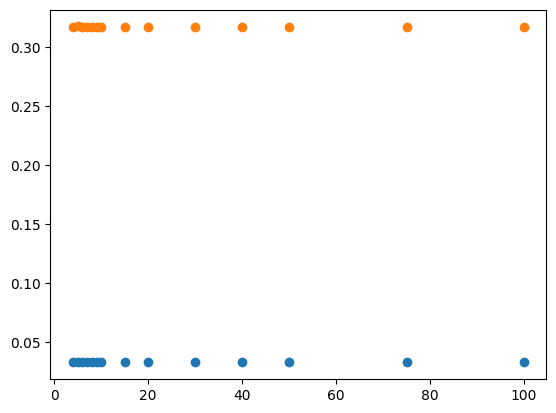

In [8]:
plt.scatter(list(score_1.keys()), list(score_1.values()))
plt.scatter(list(score_2.keys()), list(score_2.values()))

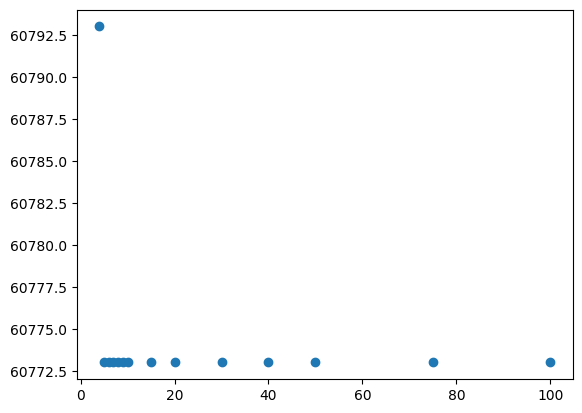

In [11]:
plt.scatter(n_niches.keys(), n_niches.values())

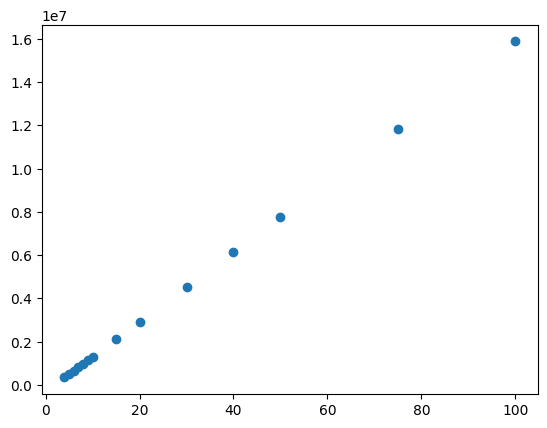

In [12]:
plt.scatter(n_pruned_connections.keys(), n_pruned_connections.values())